<a href="https://colab.research.google.com/github/125109486-dev/IS6611-HealthFlow/blob/main/IS6611_G2_DataPrep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import random
import math as math
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df1_trolleygar = pd.read_csv('https://raw.githubusercontent.com/125109486-dev/datasets/refs/heads/main/1_trolleygar_clean%20(1).csv', encoding='latin-1')
df2_hospitalbeds = pd.read_csv('https://raw.githubusercontent.com/125109486-dev/datasets/refs/heads/main/2_hospital_beds_lookup.csv', encoding='latin-1')
df3_inmo = pd.read_csv('https://raw.githubusercontent.com/125109486-dev/datasets/refs/heads/main/4_inmo_clean%20(1).csv', encoding='latin-1')

In [ ]:
#Shape of Dataset 1
print("\n--- Data Summary ---")
print("\n--- Dataset Shape ---")
print(df1_trolleygar.shape)
df1_trolleygar.head()

#Shape of Dataset 2
print("\n--- Data Summary ---")
print("\n--- Dataset Shape ---")
print(df2_hospitalbeds.shape)
df2_hospitalbeds.head()

#Shape of Dataset 3
print("\n--- Data Summary ---")
print("\n--- Dataset Shape ---")
print(df3_inmo.shape)
df3_inmo.head()


--- Data Summary ---

--- Dataset Shape ---
(42, 9)
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

--- Data Summary ---

--- Dataset Shape ---
(27, 3)
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

--- Data Summary ---

--- Dataset Shape ---
(28, 12)
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
#Dataset 1 Information
print(df1_trolleygar.columns.tolist())
print("\n--- Dataset Info. ---")
print(df1_trolleygar.info())

#Dataset 2 Information
print(df2_hospitalbeds.columns.tolist())
print("\n--- Dataset Info. ---")
print(df2_hospitalbeds.info())

#Dataset 2 Information
print(df3_inmo.columns.tolist())
print("\n--- Dataset Info. ---")
print(df3_inmo.info())

['hospital', 'ed_trolleys', 'ward_trolleys', 'total_trolleys', 'surge_capacity', 'delayed_transfers', 'waiting_over_24hrs', 'over75_waiting_24hrs', 'snapshot_date']

--- Dataset Info. ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   hospital              42 non-null     object
 1   ed_trolleys           42 non-null     int64 
 2   ward_trolleys         42 non-null     int64 
 3   total_trolleys        42 non-null     int64 
 4   surge_capacity        42 non-null     int64 
 5   delayed_transfers     42 non-null     int64 
 6   waiting_over_24hrs    42 non-null     int64 
 7   over75_waiting_24hrs  42 non-null     int64 
 8   snapshot_date         42 non-null     object
dtypes: int64(7), object(2)
memory usage: 3.1+ KB
None
---------------------------------------------------------------------------------------------------------

In [ ]:
numerical_cols_df1 = df1_trolleygar.select_dtypes(include=['int64', 'float64']).columns
categorical_cols_df1 = df1_trolleygar.select_dtypes(include=['object', 'bool', 'category']).columns

numerical_cols_df2 = df2_hospitalbeds.select_dtypes(include=['int64', 'float64']).columns
categorical_cols_df2 = df2_hospitalbeds.select_dtypes(include=['object', 'bool', 'category']).columns

numerical_cols_df3 = df3_inmo.select_dtypes(include=['int64', 'float64']).columns
categorical_cols_df3 = df3_inmo.select_dtypes(include=['object', 'bool', 'category']).columns

#MISSING VALUES
#Dataset 1
print("\n--- MISSING VALUES ---")
print(df1_trolleygar[numerical_cols_df1].isnull().sum())
df1_trolleygar[numerical_cols_df1] = df1_trolleygar[numerical_cols_df1].fillna(df1_trolleygar[numerical_cols_df1].median())

# Fill Missing Values in Categorical Columns with Mode
print(df1_trolleygar[categorical_cols_df1].isnull().sum().sort_values(ascending=False))
for col in categorical_cols_df1:
  df1_trolleygar[col]=df1_trolleygar[col].fillna(df1_trolleygar[col].mode()[0])

print("\nMissing Vlaues After Handling")
print(df1_trolleygar.isnull().sum())
print(df1_trolleygar.head())

#REMOVE DUPLICATES
df1_trolleygar.drop_duplicates(inplace=True)
print("-" * 300)

#Dataset 2
print("\n--- MISSING VALUES ---")
print(df2_hospitalbeds[numerical_cols_df2].isnull().sum())
df2_hospitalbeds[numerical_cols_df2] = df2_hospitalbeds[numerical_cols_df2].fillna(df2_hospitalbeds[numerical_cols_df2].median())

# Fill Missing Values in Categorical Columns with Mode
print(df2_hospitalbeds[categorical_cols_df2].isnull().sum().sort_values(ascending=False))
for col in categorical_cols_df2:
  df2_hospitalbeds[col]=df2_hospitalbeds[col].fillna(df2_hospitalbeds[col].mode()[0])

print("\nMissing Vlaues After Handling")
print(df2_hospitalbeds.isnull().sum())
print(df2_hospitalbeds.head())

#REMOVE DUPLICATES
df2_hospitalbeds.drop_duplicates(inplace=True)
print("-" * 300)

#Dataset 3
print("\n--- MISSING VALUES ---")
print(df3_inmo[numerical_cols_df3].isnull().sum())
df3_inmo[numerical_cols_df3] = df3_inmo[numerical_cols_df3].fillna(df3_inmo[numerical_cols_df3].median())

# Fill Missing Values in Categorical Columns with Mode
print(df3_inmo[categorical_cols_df3].isnull().sum().sort_values(ascending=False))
for col in categorical_cols_df3:
  df3_inmo[col]=df3_inmo[col].fillna(df3_inmo[col].mode()[0])

print("\nMissing Vlaues After Handling")
print(df3_inmo.isnull().sum())
print(df3_inmo.head())

#REMOVE DUPLICATES
df3_inmo.drop_duplicates(inplace=True)
print("-" * 300)


--- MISSING VALUES ---
ed_trolleys             0
ward_trolleys           0
total_trolleys          0
surge_capacity          0
delayed_transfers       0
waiting_over_24hrs      0
over75_waiting_24hrs    0
dtype: int64
hospital         0
snapshot_date    0
dtype: int64

Missing Vlaues After Handling
hospital                0
ed_trolleys             0
ward_trolleys           0
total_trolleys          0
surge_capacity          0
delayed_transfers       0
waiting_over_24hrs      0
over75_waiting_24hrs    0
snapshot_date           0
dtype: int64
                                  hospital  ed_trolleys  ward_trolleys  \
0                        Beaumont Hospital           12              0   
1                   Cavan General Hospital            8              0   
2         Connolly Hospital Blanchardstown            0              0   
3                    Louth County Hospital            0              0   
4  Mater Misericordiae University Hospital           22              0   

   tota

In [ ]:

#STANDARDISE TEXT - D1
df1_trolleygar[categorical_cols_df1] = df1_trolleygar[categorical_cols_df1].apply(lambda s: s.astype(str).str.strip().str.lower())
def print_unique_col_values(df):
  for categorical_cols_df1 in df.columns:
    if df[categorical_cols_df1].dtype == 'object':
      print(f'{categorical_cols_df1}: {df[categorical_cols_df1].unique()}')

#STANDARDISE TEXT - D2
df2_hospitalbeds[categorical_cols_df2] = df2_hospitalbeds[categorical_cols_df2].apply(lambda s: s.astype(str).str.strip().str.lower())
def print_unique_col_values(df):
  for categorical_cols_df2 in df.columns:
    if df[categorical_cols_df2].dtype == 'object':
      print(f'{categorical_cols_df2}: {df[categorical_cols_df2].unique()}')

#STANDARDISE TEXT - D3
df3_inmo[categorical_cols_df3] = df3_inmo[categorical_cols_df3].apply(lambda s: s.astype(str).str.strip().str.lower())
def print_unique_col_values(df):
  for categorical_cols_df3 in df.columns:
    if df[categorical_cols_df3].dtype == 'object':
      print(f'{categorical_cols_df3}: {df[categorical_cols_df3].unique()}')


In [ ]:
#Merge Datasets
df1_trolleygar.rename(columns={'hospital': 'Hospital'}, inplace=True)
df2_hospitalbeds.rename(columns={'hospital': 'Hospital'}, inplace=True)
df3_inmo.rename(columns={'hospital': 'Hospital'}, inplace=True)

df1_trolleygar["Hospital"] = df1_trolleygar["Hospital"].astype(str)
df2_hospitalbeds["Hospital"] = df2_hospitalbeds["Hospital"].astype(str)
df3_inmo["Hospital"] = df3_inmo["Hospital"].astype(str)

merged = df2_hospitalbeds.merge(df1_trolleygar, on="Hospital", how="left") \
                 .merge(df3_inmo, on="Hospital", how="left")

In [ ]:
#Remove the duplicate Bantry row
merged = merged.drop_duplicates(subset=['Hospital'], keep='first').reset_index(drop=True)

#Capitalise hospital names properly
merged['Hospital'] = merged['Hospital'].str.title()

#Print changes
print(f"Rows: {len(merged)}")
print(f"Hospitals: {merged['Hospital'].nunique()}")
print(merged['Hospital'].tolist())

print(f"Total hospitals: {merged['Hospital'].nunique()}")
for h in sorted(merged['Hospital'].dropna().unique()):
    print(f"  {h}")

print(merged.shape)
merged.head()

Rows: 27
Hospitals: 27
['Bantry General Hospital', 'Beaumont Hospital', 'Cavan General Hospital', 'Connolly Hospital Blanchardstown', 'Cork University Hospital', 'Ennis Hospital', 'Galway University Hospitals', 'Letterkenny University Hospital', 'Mater Misericordiae University Hospital', 'Mayo University Hospital', 'Mercy University Hospital', 'Midland Regional Hospital Mullingar', 'Midland Regional Hospital Portlaoise', 'Naas General Hospital', 'Our Lady Of Lourdes Hospital', "Our Lady'S Children'S Hospital Crumlin", 'Portiuncula University Hospital', 'Sligo University Hospital', 'St Jamess Hospital', 'St Lukes General Hospital', "St. Vincent'S University Hospital", 'Tallaght University Hospital', 'Temple Street Childrens University Hospital', 'Tipperary University Hospital', 'University Hospital Kerry', 'University Hospital Limerick', 'Wexford General Hospital']
Total hospitals: 27
  Bantry General Hospital
  Beaumont Hospital
  Cavan General Hospital
  Connolly Hospital Blanchardsto

,Hospital,hospital_beds,source,ed_trolleys,ward_trolleys,total_trolleys,surge_capacity,delayed_transfers,waiting_over_24hrs,over75_waiting_24hrs,...,daily_ed_trolleys,daily_ward_trolleys,daily_total,weekly_ed_trolleys,weekly_ward_trolleys,weekly_total,yearly_ed_trolleys,yearly_ward_trolleys,yearly_total,snapshot_date_y
0,Bantry General Hospital,46,doh open beds report march 2021,0.0,0.0,0.0,0.0,9.0,0.0,0.0,...,0.0,3.0,3.0,38.0,0.0,38.0,438.0,0.0,438.0,2026-05-19
1,Beaumont Hospital,718,doh open beds report march 2021,12.0,0.0,12.0,26.0,24.0,0.0,0.0,...,19.0,0.0,19.0,149.0,0.0,149.0,1455.0,0.0,1455.0,2026-05-19
2,Cavan General Hospital,231,doh open beds report march 2021,8.0,0.0,8.0,6.0,3.0,0.0,0.0,...,9.0,0.0,9.0,111.0,0.0,111.0,2432.0,1764.0,4196.0,2026-05-19
3,Connolly Hospital Blanchardstown,303,doh open beds report march 2021,0.0,0.0,0.0,4.0,4.0,0.0,0.0,...,6.0,0.0,6.0,57.0,0.0,57.0,1471.0,0.0,1471.0,2026-05-19
4,Cork University Hospital,664,doh open beds report march 2021,29.0,10.0,39.0,46.0,37.0,4.0,1.0,...,34.0,10.0,44.0,382.0,91.0,473.0,0.0,548.0,548.0,2026-05-19


In [ ]:
#Derived Fields
#fill daily_total missing values
if 'daily_total' in merged.columns:
    merged['trolley_load'] = merged['total_trolleys'].fillna(merged['daily_total'])
else:
    merged['trolley_load'] = merged['total_trolleys']

for name, trolleys in [('Jamess', 14), ('Lukes', 12), ('Temple Street', 1)]:
    mask = merged['Hospital'].str.contains(name, case=False, na=False)
    merged.loc[mask, 'trolley_load'] = trolleys

#Occupancy Rate = trolley load ÷ hospital beds × 100
merged['occupancy_rate_pct'] = (
    merged['trolley_load'] / merged['hospital_beds'] * 100
).round(1)

#capitalisation fix
merged['Hospital'] = (merged['Hospital']
    .str.replace("'S ", "'s ", regex=False)
    .str.replace(' Of ', ' of ', regex=False))

#Traffic Light Status
merged['traffic_light_status'] = merged['occupancy_rate_pct'].apply(
    lambda x: 'Red' if x >= 8 else ('Amber' if x >= 4 else ('Green' if pd.notna(x) else 'Unknown'))
)

#Result
print(merged[['Hospital', 'occupancy_rate_pct', 'traffic_light_status']].to_string(index=False))
print(f"\nTraffic lights: {merged['traffic_light_status'].value_counts().to_dict()}")
print(f"Still NaN: {merged['occupancy_rate_pct'].isna().sum()}")


                                   Hospital  occupancy_rate_pct traffic_light_status
                    Bantry General Hospital                 0.0                Green
                          Beaumont Hospital                 1.7                Green
                     Cavan General Hospital                 3.5                Green
           Connolly Hospital Blanchardstown                 0.0                Green
                   Cork University Hospital                 5.9                Amber
                             Ennis Hospital                 0.0                Green
                Galway University Hospitals                 4.4                Amber
            Letterkenny University Hospital                 1.7                Green
    Mater Misericordiae University Hospital                 3.2                Green
                   Mayo University Hospital                 8.6                  Red
                  Mercy University Hospital                 1.5  

In [ ]:
from datetime import date

#Wait Tier
merged['wait_tier'] = merged['waiting_over_24hrs'].apply(
    lambda x: 'High breach' if x > 15 else ('Moderate breach' if x > 5 else ('Low breach' if x > 0 else 'No breach'))
)

#Bank Holiday Flag
bank_holidays_2026 = [
    '2026-01-01','2026-02-02','2026-03-17','2026-04-03',
    '2026-04-06','2026-05-04','2026-06-01','2026-08-03',
    '2026-10-26','2026-12-25','2026-12-26'
]
merged['is_bank_holiday'] = str(date.today()) in bank_holidays_2026

print(merged[['Hospital', 'waiting_over_24hrs', 'wait_tier', 'is_bank_holiday']].to_string(index=False))

                                   Hospital  waiting_over_24hrs       wait_tier  is_bank_holiday
                    Bantry General Hospital                 0.0       No breach            False
                          Beaumont Hospital                 0.0       No breach            False
                     Cavan General Hospital                 0.0       No breach            False
           Connolly Hospital Blanchardstown                 0.0       No breach            False
                   Cork University Hospital                 4.0      Low breach            False
                             Ennis Hospital                 0.0       No breach            False
                Galway University Hospitals                 3.0      Low breach            False
            Letterkenny University Hospital                 0.0       No breach            False
    Mater Misericordiae University Hospital                 1.0      Low breach            False
                   Mayo Univer

In [ ]:
print(merged.shape)
merged.head()

(27, 27)


,Hospital,hospital_beds,source,ed_trolleys,ward_trolleys,total_trolleys,surge_capacity,delayed_transfers,waiting_over_24hrs,over75_waiting_24hrs,...,weekly_total,yearly_ed_trolleys,yearly_ward_trolleys,yearly_total,snapshot_date_y,trolley_load,occupancy_rate_pct,traffic_light_status,wait_tier,is_bank_holiday
0,Bantry General Hospital,46,doh open beds report march 2021,0.0,0.0,0.0,0.0,9.0,0.0,0.0,...,38.0,438.0,0.0,438.0,2026-05-19,0.0,0.0,Green,No breach,False
1,Beaumont Hospital,718,doh open beds report march 2021,12.0,0.0,12.0,26.0,24.0,0.0,0.0,...,149.0,1455.0,0.0,1455.0,2026-05-19,12.0,1.7,Green,No breach,False
2,Cavan General Hospital,231,doh open beds report march 2021,8.0,0.0,8.0,6.0,3.0,0.0,0.0,...,111.0,2432.0,1764.0,4196.0,2026-05-19,8.0,3.5,Green,No breach,False
3,Connolly Hospital Blanchardstown,303,doh open beds report march 2021,0.0,0.0,0.0,4.0,4.0,0.0,0.0,...,57.0,1471.0,0.0,1471.0,2026-05-19,0.0,0.0,Green,No breach,False
4,Cork University Hospital,664,doh open beds report march 2021,29.0,10.0,39.0,46.0,37.0,4.0,1.0,...,473.0,0.0,548.0,548.0,2026-05-19,39.0,5.9,Amber,Low breach,False


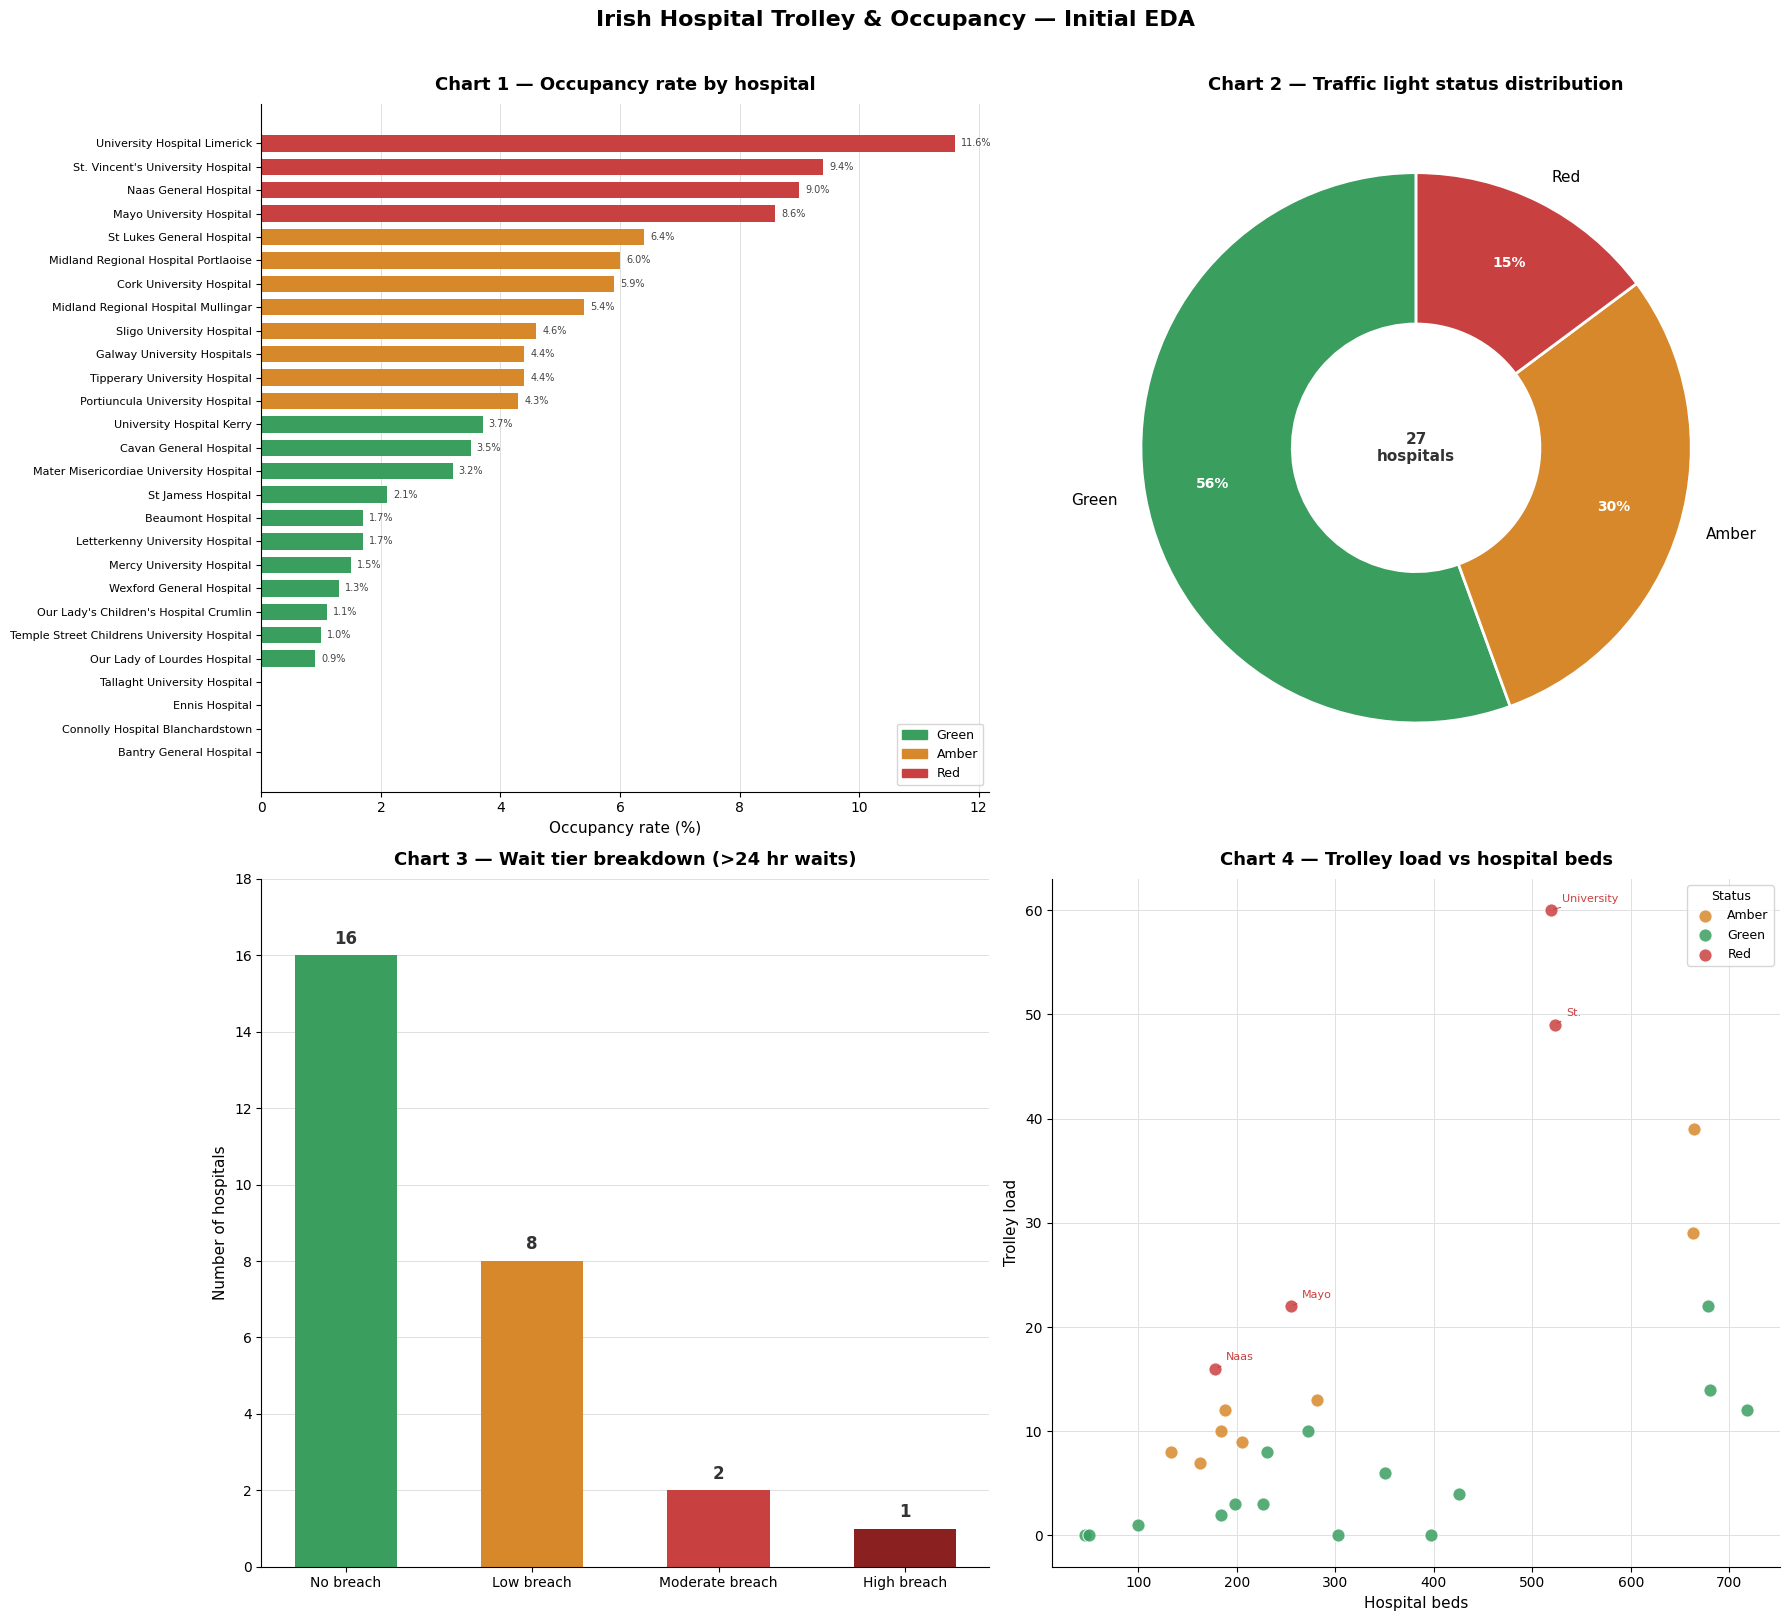

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from datetime import date

warnings.filterwarnings('ignore')

#Load & clean datasets
df1 = pd.read_csv('https://raw.githubusercontent.com/125109486-dev/datasets/refs/heads/main/1_trolleygar_clean%20(1).csv', encoding='latin-1')
df2 = pd.read_csv('https://raw.githubusercontent.com/125109486-dev/datasets/refs/heads/main/2_hospital_beds_lookup.csv', encoding='latin-1')
df3 = pd.read_csv('https://raw.githubusercontent.com/125109486-dev/datasets/refs/heads/main/4_inmo_clean%20(1).csv', encoding='latin-1')

for df in [df1, df2, df3]:
    for col in df.select_dtypes(include='number').columns:
        df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip().str.lower()
        df[col].fillna(df[col].mode()[0], inplace=True)

df1.rename(columns={'hospital': 'Hospital'}, inplace=True)
df2.rename(columns={'hospital': 'Hospital'}, inplace=True)
df3.rename(columns={'hospital': 'Hospital'}, inplace=True)

merged = df2.merge(df1, on='Hospital', how='left').merge(df3, on='Hospital', how='left')
merged = merged.drop_duplicates(subset=['Hospital'], keep='first').reset_index(drop=True)
merged['Hospital'] = merged['Hospital'].str.title()

if 'daily_total' in merged.columns:
    merged['trolley_load'] = merged['total_trolleys'].fillna(merged['daily_total'])
else:
    merged['trolley_load'] = merged['total_trolleys']

for name, trolleys in [('Jamess', 14), ('Lukes', 12), ('Temple Street', 1)]:
    mask = merged['Hospital'].str.contains(name, case=False, na=False)
    merged.loc[mask, 'trolley_load'] = trolleys

merged['occupancy_rate_pct'] = (merged['trolley_load'] / merged['hospital_beds'] * 100).round(1)
merged['Hospital'] = (merged['Hospital']
    .str.replace("'S ", "'s ", regex=False)
    .str.replace(' Of ', ' of ', regex=False))

merged['traffic_light_status'] = merged['occupancy_rate_pct'].apply(
    lambda x: 'Red' if x >= 8 else ('Amber' if x >= 4 else ('Green' if pd.notna(x) else 'Unknown'))
)

merged['wait_tier'] = merged['waiting_over_24hrs'].apply(
    lambda x: 'High breach' if x > 15 else ('Moderate breach' if x > 5 else ('Low breach' if x > 0 else 'No breach'))
)

bank_holidays_2026 = ['2026-01-01','2026-02-02','2026-03-17','2026-04-03',
                      '2026-04-06','2026-05-04','2026-06-01','2026-08-03',
                      '2026-10-26','2026-12-25','2026-12-26']
merged['is_bank_holiday'] = str(date.today()) in bank_holidays_2026

#Colour maps
STATUS_COLORS = {'Green': '#3a9e5f', 'Amber': '#d6882a', 'Red': '#c94040', 'Unknown': '#888888'}
TIER_COLORS = {'No breach': '#3a9e5f', 'Low breach': '#d6882a',
                 'Moderate breach': '#c94040', 'High breach': '#8b2020'}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
fig.suptitle('Irish Hospital Trolley & Occupancy — Initial EDA', fontsize=16, fontweight='bold', y=1.01)
plt.subplots_adjust(hspace=0.45, wspace=0.35)

#Occupancy rate by hospital
ax1 = axes[0, 0]
df_sorted = merged.sort_values('occupancy_rate_pct', ascending=True)
bar_colors = df_sorted['traffic_light_status'].map(STATUS_COLORS)

ax1.barh(df_sorted['Hospital'], df_sorted['occupancy_rate_pct'],
         color=bar_colors, edgecolor='none', height=0.7)
ax1.set_xlabel('Occupancy rate (%)', fontsize=11)
ax1.set_title('Chart 1 — Occupancy rate by hospital', pad=10)
ax1.tick_params(axis='y', labelsize=8)
ax1.tick_params(axis='x', labelsize=10)
ax1.xaxis.grid(True, color='#e0e0e0', linewidth=0.7)
ax1.set_axisbelow(True)

legend_handles = [mpatches.Patch(color=c, label=l) for l, c in STATUS_COLORS.items() if l != 'Unknown']
ax1.legend(handles=legend_handles, fontsize=9, loc='lower right')

for bar, val in zip(ax1.patches, df_sorted['occupancy_rate_pct']):
    if val > 0:
        ax1.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=7, color='#444')

#Traffic light status
ax2 = axes[0, 1]
status_counts = merged['traffic_light_status'].value_counts()
status_order  = [s for s in ['Green', 'Amber', 'Red', 'Unknown'] if s in status_counts.index]
sizes  = status_counts[status_order]
colors = [STATUS_COLORS[s] for s in status_order]

wedges, texts, autotexts = ax2.pie(
    sizes, labels=status_order, colors=colors,
    autopct='%1.0f%%', startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.75
)
for t in texts:     t.set_fontsize(11)
for at in autotexts:
    at.set_fontsize(10); at.set_color('white'); at.set_fontweight('bold')

ax2.add_patch(plt.Circle((0, 0), 0.35, fc='white'))
ax2.text(0, 0, f"{len(merged)}\nhospitals", ha='center', va='center',
         fontsize=11, fontweight='bold', color='#333')
ax2.set_title('Chart 2 — Traffic light status distribution', pad=10)

#Wait tier breakdown
ax3 = axes[1, 0]
tier_order  = ['No breach', 'Low breach', 'Moderate breach', 'High breach']
tier_counts = merged['wait_tier'].value_counts().reindex(tier_order, fill_value=0)
tier_colors = [TIER_COLORS[t] for t in tier_order]

bars = ax3.bar(tier_order, tier_counts.values, color=tier_colors, edgecolor='none', width=0.55)
ax3.set_ylabel('Number of hospitals', fontsize=11)
ax3.set_title('Chart 3 — Wait tier breakdown (>24 hr waits)', pad=10)
ax3.tick_params(axis='x', labelsize=10)
ax3.yaxis.grid(True, color='#e0e0e0', linewidth=0.7)
ax3.set_axisbelow(True)
ax3.set_ylim(0, tier_counts.max() + 2)

for bar, val in zip(bars, tier_counts.values):
    ax3.text(bar.get_x() + bar.get_width() / 2, val + 0.2,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333')

#Trolley load vs hospital beds
ax4 = axes[1, 1]
for status, group in merged.groupby('traffic_light_status'):
    ax4.scatter(group['hospital_beds'], group['trolley_load'],
                color=STATUS_COLORS.get(status, '#888'),
                label=status, s=90, alpha=0.85, edgecolors='white', linewidths=0.8)

for _, row in merged[merged['traffic_light_status'] == 'Red'].iterrows():
    ax4.annotate(row['Hospital'].split(' ')[0],
                 xy=(row['hospital_beds'], row['trolley_load']),
                 xytext=(8, 6), textcoords='offset points',
                 fontsize=8, color='#c94040',
                 arrowprops=dict(arrowstyle='-', color='#c94040', lw=0.7))

ax4.set_xlabel('Hospital beds', fontsize=11)
ax4.set_ylabel('Trolley load', fontsize=11)
ax4.set_title('Chart 4 — Trolley load vs hospital beds', pad=10)
ax4.legend(title='Status', fontsize=9, title_fontsize=9)
ax4.xaxis.grid(True, color='#e0e0e0', linewidth=0.7)
ax4.yaxis.grid(True, color='#e0e0e0', linewidth=0.7)
ax4.set_axisbelow(True)

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#from google.colab import files
#merged.to_csv('master_table.csv', index=False)
#files.download('master_table.csv')
#made it a note so it would redownload everytime it was run

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
inmo_name_map = {
    'st james\x92s hospital': "st. james's hospital",
    'st jamesâ\x92s hospital': "st. james's hospital",
    'st luke\x92s general hospital, kilkenny': "st luke's general hospital kilkenny",
    'st lukeâ\x92s general hospital, kilkenny': "st luke's general hospital kilkenny",
    'temple street children\x92s university hospital': 'chi at temple street',
    'temple street childrenâ\x92s university hospital': 'chi at temple street',
    "our lady's children's hospital crumlin": 'chi at crumlin',
}
df3_inmo['Hospital'] = df3_inmo['Hospital'].replace(inmo_name_map)

print('Fixed! Checking results:')
for h in sorted(df3_inmo['Hospital'].unique()):
    print(f'  {h}')

Fixed! Checking results:
  bantry general hospital
  beaumont hospital
  cavan general hospital
  chi at crumlin
  chi at temple street
  connolly hospital blanchardstown
  cork university hospital
  ennis hospital
  galway university hospitals
  letterkenny university hospital
  mater misericordiae university hospital
  mayo university hospital
  mercy university hospital
  midland regional hospital mullingar
  midland regional hospital portlaoise
  naas general hospital
  our lady of lourdes hospital
  portiuncula university hospital
  sligo university hospital
  st luke's general hospital kilkenny
  st. james's hospital
  st. vincent's university hospital
  tallaght university hospital
  tipperary university hospital
  university hospital kerry
  university hospital limerick
  wexford general hospital


In [ ]:
mgt = pd.read_csv('https://raw.githubusercontent.com/125109486-dev/datasets/refs/heads/main/dataset3_mgt_report_clean%20(1).csv')
print('MGT loaded:', mgt.shape)
print('Columns:', list(mgt.columns))

MGT loaded: (5201, 7)
Columns: ['Year', 'Month', 'Date', 'Hospital', 'KPI', 'Attendances', 'is_synthetic']


In [ ]:
#Prepare data for EDA
all_em = mgt[mgt['KPI'] == 'all_emergency_presentations'].copy()

#Take out group-level entries
exclude = [
    'Acute Hospitals Division', 'Acute Hospitals Operations', 'Acute Non Hospital',
    'Dublin Midlands Hospital Group', 'Ireland East Hospital Group',
    'RCSI Hospitals Group', 'Saolta University Health Care Group',
    'South/South West Hospital Group', 'UL Hospitals Group',
    "Children's Health Ireland"
]
all_em = all_em[~all_em['Hospital'].isin(exclude)]

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
year_colors = {'2022': '#2E86AB', '2023': '#A23B72', '2024': '#F18F01'}

print(f'Hospitals: {all_em["Hospital"].nunique()}')
print(f'Years: {sorted(all_em["Year"].unique())}')
print(f'KPI: {all_em["KPI"].unique()}')

Hospitals: 35
Years: [np.int64(2022), np.int64(2023), np.int64(2024)]
KPI: ['all_emergency_presentations']


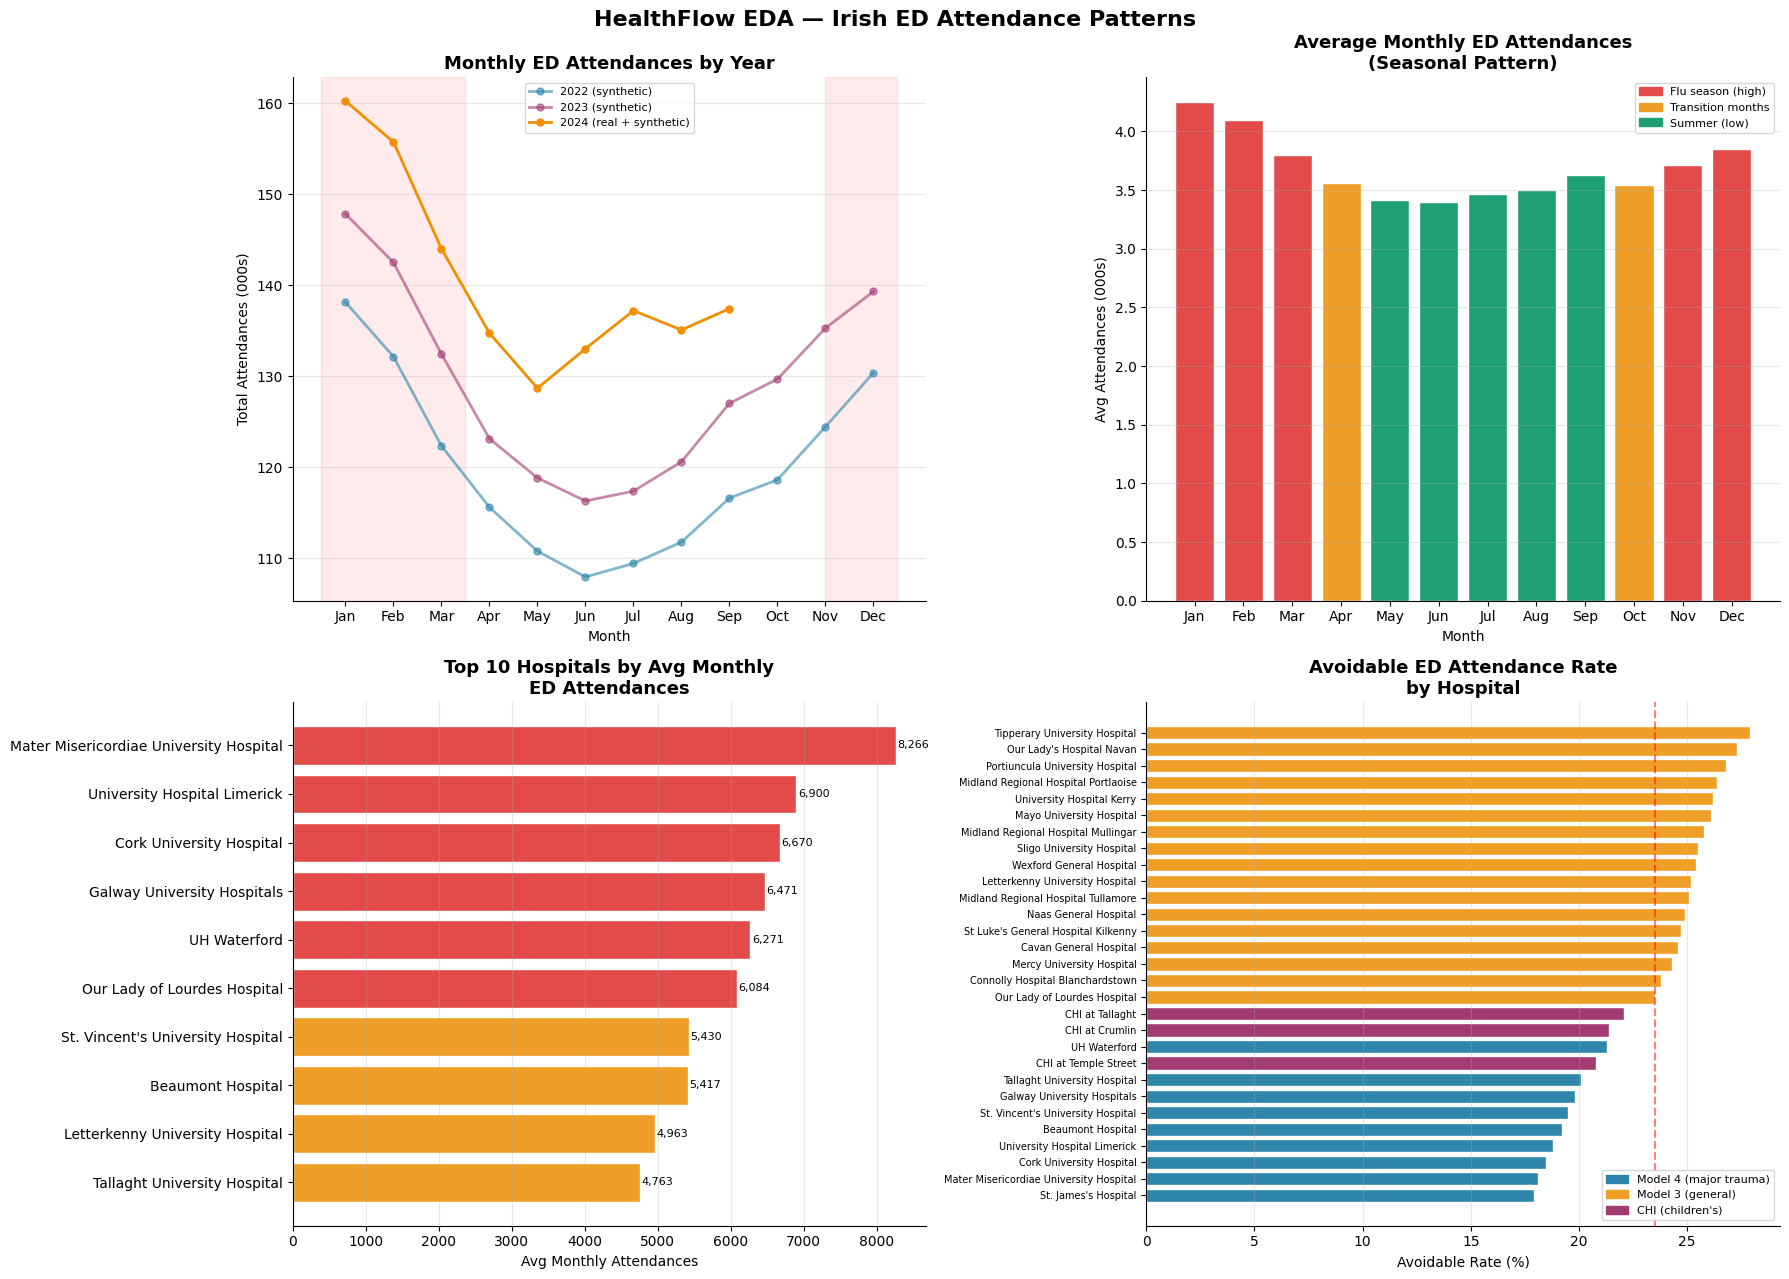

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('HealthFlow EDA — Irish ED Attendance Patterns', fontsize=16, fontweight='bold')

#Monthly trend by year
ax1 = axes[0,0]
for year in [2022, 2023, 2024]:
    yr_data = all_em[all_em['Year']==year].groupby('Month')['Attendances'].sum()
    alpha = 0.6 if year in [2022,2023] else 1.0
    label = f'{year} (synthetic)' if year in [2022,2023] else f'{year} (real + synthetic)'
    ax1.plot(yr_data.index, yr_data.values/1000, '-o',
             color=year_colors[str(year)], label=label, alpha=alpha, linewidth=2, markersize=5)
ax1.set_title('Monthly ED Attendances by Year', fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Attendances (000s)')
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(month_names)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)
ax1.axvspan(11, 12.5, alpha=0.08, color='red')
ax1.axvspan(0.5, 3.5, alpha=0.08, color='red')

#Average seasonal pattern
ax2 = axes[0,1]
seasonal_avg = all_em.groupby('Month')['Attendances'].mean()
bar_colors = ['#E24B4A' if m in [1,2,3,11,12] else '#EF9F27' if m in [4,10] else '#1D9E75'
              for m in range(1,13)]
ax2.bar(range(1,13), seasonal_avg.values/1000, color=bar_colors, edgecolor='white')
ax2.set_title('Average Monthly ED Attendances\n(Seasonal Pattern)', fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Avg Attendances (000s)')
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(month_names)
ax2.grid(axis='y', alpha=0.3)
red_patch = mpatches.Patch(color='#E24B4A', label='Flu season (high)')
amber_patch = mpatches.Patch(color='#EF9F27', label='Transition months')
green_patch = mpatches.Patch(color='#1D9E75', label='Summer (low)')
ax2.legend(handles=[red_patch, amber_patch, green_patch], fontsize=8)

#Top 10 hospitals by avg attendance
ax3 = axes[1,0]
top10 = all_em.groupby('Hospital')['Attendances'].mean().nlargest(10).sort_values()
bar_col_top = ['#E24B4A' if v > 6000 else '#EF9F27' if v > 4000 else '#1D9E75' for v in top10.values]
bars = ax3.barh(top10.index, top10.values, color=bar_col_top, edgecolor='white')
ax3.set_title('Top 10 Hospitals by Avg Monthly\nED Attendances', fontweight='bold')
ax3.set_xlabel('Avg Monthly Attendances')
ax3.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top10.values):
    ax3.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', va='center', fontsize=8)

#Avoidable rate by hospital
ax4 = axes[1,1]
avoidable_data = {
    'Beaumont Hospital': ('Model 4', 19.2),
    'Cork University Hospital': ('Model 4', 18.5),
    'Galway University Hospitals': ('Model 4', 19.8),
    'Mater Misericordiae University Hospital': ('Model 4', 18.1),
    "St. James's Hospital": ('Model 4', 17.9),
    "St. Vincent's University Hospital": ('Model 4', 19.5),
    'Tallaght University Hospital': ('Model 4', 20.1),
    'University Hospital Limerick': ('Model 4', 18.8),
    'UH Waterford': ('Model 4', 21.3),
    'Cavan General Hospital': ('Model 3', 24.6),
    'Connolly Hospital Blanchardstown': ('Model 3', 23.8),
    'Letterkenny University Hospital': ('Model 3', 25.2),
    'Mayo University Hospital': ('Model 3', 26.1),
    'Mercy University Hospital': ('Model 3', 24.3),
    'Midland Regional Hospital Mullingar': ('Model 3', 25.8),
    'Midland Regional Hospital Portlaoise': ('Model 3', 26.4),
    'Midland Regional Hospital Tullamore': ('Model 3', 25.1),
    'Naas General Hospital': ('Model 3', 24.9),
    'Our Lady of Lourdes Hospital': ('Model 3', 23.5),
    "Our Lady's Hospital Navan": ('Model 3', 27.3),
    'Portiuncula University Hospital': ('Model 3', 26.8),
    'Sligo University Hospital': ('Model 3', 25.5),
    "St Luke's General Hospital Kilkenny": ('Model 3', 24.7),
    'Tipperary University Hospital': ('Model 3', 27.9),
    'University Hospital Kerry': ('Model 3', 26.2),
    'Wexford General Hospital': ('Model 3', 25.4),
    'CHI at Crumlin': ('CHI', 21.4),
    'CHI at Tallaght': ('CHI', 22.1),
    'CHI at Temple Street': ('CHI', 20.8),
}

av_df = pd.DataFrame([(h, m, r) for h, (m, r) in avoidable_data.items()],
                     columns=['Hospital','Model','Rate'])
av_df = av_df.sort_values('Rate', ascending=True)
model_colors = {'Model 4': '#2E86AB', 'Model 3': '#EF9F27', 'CHI': '#A23B72'}
bar_col_av = [model_colors[m] for m in av_df['Model']]
ax4.barh(av_df['Hospital'], av_df['Rate'], color=bar_col_av, edgecolor='white')
ax4.set_title('Avoidable ED Attendance Rate\nby Hospital', fontweight='bold')
ax4.set_xlabel('Avoidable Rate (%)')
ax4.axvline(x=23.5, color='red', linestyle='--', alpha=0.5, label='National avg ~23.5%')
ax4.grid(axis='x', alpha=0.3)
ax4.tick_params(axis='y', labelsize=7)
m4 = mpatches.Patch(color='#2E86AB', label='Model 4 (major trauma)')
m3 = mpatches.Patch(color='#EF9F27', label='Model 3 (general)')
chi = mpatches.Patch(color='#A23B72', label="CHI (children's)")
ax4.legend(handles=[m4, m3, chi], fontsize=8)

plt.tight_layout()
plt.savefig('EDA_Attendance_Patterns.png', dpi=150, bbox_inches='tight')
plt.show()


**Sythentic Dataset Generation**

In [ ]:
import pandas as pd
import numpy as np
from datetime import date

np.random.seed(42)

master = pd.read_csv('https://raw.githubusercontent.com/125109486-dev/Health-Flow/refs/heads/main/data/master_dataset.csv', encoding='latin-1')

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

#Load master table
master = pd.read_csv('https://raw.githubusercontent.com/125109486-dev/Health-Flow/refs/heads/main/data/master_dataset.csv', encoding='latin-1')

#Bank holidays
BANK_HOLIDAYS = {
    '2022-01-03': "New Year's Day", '2022-02-07': 'St Brigid Day',
    '2022-03-17': 'St Patrick Day', '2022-04-15': 'Good Friday',
    '2022-04-18': 'Easter Monday', '2022-05-02': 'May Bank Holiday',
    '2022-06-06': 'June Bank Holiday', '2022-08-01': 'August Bank Holiday',
    '2022-10-31': 'October Bank Holiday','2022-12-26': 'St Stephen Day',
    '2023-01-02': "New Year's Day", '2023-02-06': 'St Brigid Day',
    '2023-03-17': 'St Patrick Day', '2023-04-07': 'Good Friday',
    '2023-04-10': 'Easter Monday', '2023-05-01': 'May Bank Holiday',
    '2023-06-05': 'June Bank Holiday', '2023-08-07': 'August Bank Holiday',
    '2023-10-30': 'October Bank Holiday','2023-12-25': 'Christmas Day',
    '2023-12-26': 'St Stephen Day'
}

REGION_MAP = {
    'Bantry General Hospital': 'Cork',
    'Beaumont Hospital': 'Dublin',
    'Cavan General Hospital': 'Cavan',
    'Connolly Hospital Blanchardstown': 'Dublin',
    'Cork University Hospital': 'Cork',
    'Ennis Hospital': 'Clare',
    'Galway University Hospitals': 'Galway',
    'Letterkenny University Hospital': 'Donegal',
    'Mater Misericordiae University Hospital': 'Dublin',
    'Mayo University Hospital': 'Mayo',
    'Mercy University Hospital': 'Cork',
    'Midland Regional Hospital Mullingar': 'Westmeath',
    'Midland Regional Hospital Portlaoise': 'Portlaoise',
    'Naas General Hospital': 'Kildare',
    'Our Lady of Lourdes Hospital': 'Louth',
    "Our Lady's Children's Hospital Crumlin": 'Dublin',
    'Portiuncula University Hospital': 'Galway',
    'Sligo University Hospital': 'Sligo',
    'St Jamess Hospital': 'Dublin',
    'St Lukes General Hospital': 'Kilkenny',
    "St. Vincent's University Hospital": 'Dublin',
    'Tallaght University Hospital': 'Dublin',
    'Temple Street Childrens University Hospital': 'Dublin',
    'Tipperary University Hospital': 'Tipperary',
    'University Hospital Kerry': 'Kerry',
    'University Hospital Limerick': 'Limerick',
    'Wexford General Hospital': 'Wexford',
}

SEASONAL = {1:1.35, 2:1.28, 3:1.10, 4:1.00, 5:0.95,
            6:0.90, 7:0.88, 8:0.92, 9:0.98, 10:1.05,
            11:1.15, 12:1.25}

YOY = {2022: 0.93, 2023: 0.97}

date_range = pd.date_range(start='2022-01-01', end='2024-05-31', freq='D')

rows = []

for _, hosp_row in master.iterrows():
    hospital = hosp_row['Hospital']
    beds = int(hosp_row['hospital_beds'])
    base_trolleys = float(hosp_row['trolley_load']) if hosp_row['trolley_load'] > 0 else 5.0
    real_delayed  = float(hosp_row.get('delayed_transfers', 0) or 0)

    yearly_total_raw = hosp_row.get('yearly_total', None)
    yearly_total = float(yearly_total_raw) if pd.notna(yearly_total_raw) and yearly_total_raw != 0 else base_trolleys * 365

    for d in date_range:
        ds = d.strftime('%Y-%m-%d')

        #Bank holiday lookup
        is_bh = ds in BANK_HOLIDAYS
        bh_name = BANK_HOLIDAYS[ds] if is_bh else ''

        seasonal = SEASONAL[d.month]
        yoy = YOY.get(d.year, 1.0)
        is_weekend = d.weekday() >= 5
        is_monday = d.weekday() == 0
        is_flu_season = d.month in [11, 12, 1, 2]
        is_flu_peak = d.month in [1, 2]

        bh_factor = 1.40 if is_bh else 1.0
        mon_factor = 1.22 if is_monday and is_bh else (1.10 if is_monday else 1.0)
        weekend_factor = 0.82 if is_weekend and not is_bh else 1.0
        flu_factor = 1.15 if is_flu_peak else (1.08 if is_flu_season else 1.0)

        #Add noise factor (dataset looks flat without it)
        noise = np.random.normal(1.0, 0.08)
        trolleys = max(0, round(
            base_trolleys * seasonal * yoy * bh_factor
            * mon_factor * weekend_factor * flu_factor * noise, 1
        ))

        ed_trolleys = round(trolleys * np.random.uniform(0.65, 0.75), 1)
        ward_trolleys = round(trolleys - ed_trolleys, 1)
        occ = round(trolleys / beds * 100, 1) if beds > 0 else 0.0

        if occ >= 8: traffic = 'Red'
        elif occ >= 4: traffic = 'Amber'
        else: traffic = 'Green'

        #Waiting over 24hrs
        if traffic == 'Red':
            wait_24 = max(1, round(trolleys * np.random.uniform(0.15, 0.35) * noise))
        elif traffic == 'Amber':
            wait_24 = max(0, round(trolleys * np.random.uniform(0.05, 0.15) * noise))
        else:
            wait_24 = max(0, round(np.random.poisson(0.3)))

        over75 = round(wait_24 * np.random.uniform(0.20, 0.30)) if wait_24 > 0 else 0

        #Surge capacity
        if traffic == 'Red':
            surge = max(1, round(beds * np.random.uniform(0.08, 0.20) * noise * 0.6))
        elif traffic == 'Amber':
            surge = max(0, round(beds * np.random.uniform(0.02, 0.08) * noise * 0.5))
        else:
            surge = max(0, round(np.random.poisson(0.2)))

        #Delayed transfers
        if real_delayed > 0:
            delayed = max(0, round(real_delayed * seasonal * yoy * noise))
        else:
            if traffic == 'Red':
                delayed = max(0, round(np.random.poisson(8) * seasonal))
            elif traffic == 'Amber':
                delayed = max(0, round(np.random.poisson(4) * 0.7))
            else:
                delayed = max(0, round(np.random.poisson(1.5)))

        #Wait tier
        if wait_24 > 15: wait_tier = 'High breach'
        elif wait_24 > 5: wait_tier = 'Moderate breach'
        elif wait_24 > 0: wait_tier = 'Low breach'
        else: wait_tier = 'No breach'

        season_name = ('Winter' if d.month in [12, 1, 2] else
                       'Spring' if d.month in [3, 4, 5] else
                       'Summer' if d.month in [6, 7, 8] else 'Autumn')

        yearly_base = yearly_total if pd.notna(yearly_total) and yearly_total > 0 else base_trolleys * 365
        yearly_est = round(yearly_base * yoy * seasonal * np.random.uniform(0.97, 1.03))

        rows.append({
            'Hospital': hospital,
            'region': REGION_MAP.get(hospital, 'Unknown'),
            'source': 'synthetic',
            'date': ds,
            'year': d.year,
            'month': d.month,
            'day_of_week': d.day_name(),
            'season': season_name,
            'is_bank_holiday': is_bh,
            'bank_holiday_name': bh_name,
            'is_weekend': is_weekend,
            'is_flu_season': is_flu_season,
            'is_flu_peak': is_flu_peak,
            'hospital_beds': beds,
            'ed_trolleys': ed_trolleys,
            'ward_trolleys': ward_trolleys,
            'total_trolleys': trolleys,
            'trolley_load': trolleys,
            'daily_ed_trolleys': ed_trolleys,
            'daily_ward_trolleys': ward_trolleys,
            'daily_total': trolleys,
            'weekly_ed_trolleys': round(ed_trolleys * 7),
            'weekly_ward_trolleys': round(ward_trolleys * 7),
            'weekly_total': round(trolleys * 7 * np.random.uniform(0.95, 1.05)),
            'yearly_ed_trolleys': round(ed_trolleys * 365 * yoy),
            'yearly_ward_trolleys': round(ward_trolleys * 365 * yoy),
            'yearly_total': yearly_est,
            'surge_capacity': surge,
            'delayed_transfers': delayed,
            'waiting_over_24hrs': wait_24,
            'over75_waiting_24hrs': over75,
            'occupancy_rate_pct': occ,
            'traffic_light_status': traffic,
            'wait_tier': wait_tier,
            'is_synthetic': True,
        })

#Build dataframe
synthetic = pd.DataFrame(rows)
synthetic = synthetic.sort_values(['date', 'Hospital']).reset_index(drop=True)

#Verification
print(f"Shape: {synthetic.shape}")
print(f"Hospitals: {synthetic['Hospital'].nunique()}")
print(f"Nulls: {synthetic.isnull().sum().sum()}")
print(f"\nBank holidays captured:")
print(synthetic[synthetic['bank_holiday_name'] != ''][['date','bank_holiday_name']]
      .drop_duplicates().to_string(index=False))
print(f"\nWait tier distribution:")
print(synthetic['wait_tier'].value_counts().to_string())
print(f"\nTraffic light distribution:")
print(synthetic['traffic_light_status'].value_counts().to_string())

synthetic['bank_holiday_name'] = synthetic['bank_holiday_name'].replace('', 'Not a Bank Holiday')
synthetic['bank_holiday_name'] = synthetic['bank_holiday_name'].fillna('Not a Bank Holiday')

synthetic.to_csv('synthetic_dataset.csv', index=False)

#Made this a comment so it wouldnt keep saving whenever it was run
#Save
#synthetic.to_csv('synthetic_dataset.csv', index=False)
#print("\nSaved: synthetic_dataset.csv")

#from google.colab import files
#files.download('synthetic_dataset.csv')

Shape:     (23814, 35)
Hospitals: 27
Nulls:     0

Bank holidays captured:
      date    bank_holiday_name
2022-01-03       New Year's Day
2022-02-07        St Brigid Day
2022-03-17       St Patrick Day
2022-04-15          Good Friday
2022-04-18        Easter Monday
2022-05-02     May Bank Holiday
2022-06-06    June Bank Holiday
2022-08-01  August Bank Holiday
2022-10-31 October Bank Holiday
2022-12-26       St Stephen Day
2023-01-02       New Year's Day
2023-02-06        St Brigid Day
2023-03-17       St Patrick Day
2023-04-07          Good Friday
2023-04-10        Easter Monday
2023-05-01     May Bank Holiday
2023-06-05    June Bank Holiday
2023-08-07  August Bank Holiday
2023-10-30 October Bank Holiday
2023-12-25        Christmas Day
2023-12-26       St Stephen Day

Wait tier distribution:
wait_tier
Low breach         12159
No breach           9207
Moderate breach     1714
High breach          734

Traffic light distribution:
traffic_light_status
Green    11838
Amber     7080
Red   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>